# DTLZ4 Results

In [3]:
import multiprocessing
from functools import partial
from meamt_core import build_toolbox, gen_inicial_tables, run, generate_dtlz3_front_random
from deap import benchmarks

# 1. Parâmetros
K = 5
NPOP = 1280
NGEN = 500
NOBJ = 5 
IND_SIZE = NOBJ + K - 1 
NUM_TABLES = int((1 << NOBJ)) 
MAX_TABLE_SIZE = int(NPOP / NUM_TABLES)
REF_POINT_HV = [1.1]*NOBJ

# 2. Configurando o Toolbox de forma segura para o multiprocessing
# O 'partial' "congela" o argumento obj=NOBJ na função nativa do DEAP
func_dtlz4_segura = partial(benchmarks.dtlz4, obj=NOBJ, alpha=100)
toolbox = build_toolbox(func_dtlz4_segura, IND_SIZE, NPOP, NOBJ)

# =======================================================
# A TRAVA DE SEGURANÇA (OBRIGATÓRIA NO JUPYTER/WINDOWS)
# =======================================================
if __name__ == '__main__':
    # Cria o pool apenas se for o processo principal
    num_cores = multiprocessing.cpu_count() - 1 
    pool = multiprocessing.Pool(processes=num_cores)
    toolbox.register("map", pool.map) 

    # 3. Inicialização
    pop_inicial = toolbox.population()
    
    # Avaliação inicial
    fitnesses = toolbox.map(toolbox.evaluate, pop_inicial)
    for ind, fit in zip(pop_inicial, fitnesses):
        ind.fitness.values = fit

    tabelas = gen_inicial_tables(pop_inicial, NUM_TABLES, MAX_TABLE_SIZE, NOBJ)
    pareto_real = generate_dtlz3_front_random(NOBJ, 1000)
    reset = 40
    print(f"Iniciando evolução usando {num_cores} threads...")

    # 4. Executando o MEAMT
    logbook = run(tabelas, pareto_real, NUM_TABLES, MAX_TABLE_SIZE, NGEN, toolbox, 0.9, 1.0, REF_POINT_HV, NOBJ, reset)

    # Fechando os processos corretamente
    pool.close()
    pool.join()

    print("Evolução concluída!")

Iniciando evolução usando 15 threads...
Evolução concluída!


(2.2958450216584857e-49, 0.0, 3.749399456654674e-33, 6.123233995736815e-17, 1.000000000000008)
(1.405799628556223e-65, 2.2958450216584823e-49, 3.749399456654668e-33, 6.123233995736805e-17, 1.0000000000000064)
(6.123235494996051e-17, 0.0, 0.0, 0.0, 1.0000002448476224)
(6.123233995736815e-17, 1.000000000000008, 0.0, 0.0, 0.0)
(3.749399456654668e-33, 0.0, 0.0, 6.123233995736805e-17, 1.0000000000000064)
(1.000000001271689, 0.0, 0.0, 0.0, 0.0)
(1.000000001271689, 0.0, 0.0, 0.0, 0.0)
(0.04131681361761602, 0.0, 1.0283805079441354e-33, 1.5990782405269781, 4.2906583313674823e-51)
(0.022854436784346788, 0.0, 1.6690383835714742, 0.027302367927429315, 3.542266815355602e-86)
(1.4197828153685604e-33, 2.3186812987337546e-17, 7.204860407033425e-17, 5.256949375599569e-215, 1.23607412967692)
(0.10738974062242282, 3.2234261386712914e-235, 1.2988452388158198, 0.0, 0.019472482768378256)
(0.17332033901684982, 0.2871832523201186, 0.46297568981746273, 0.39720808668437024, 0.7202557563947104)
(0.31039244360764

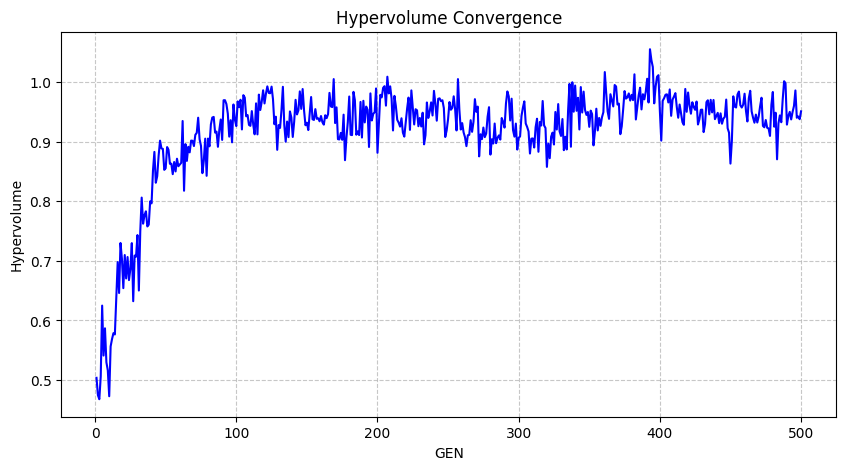

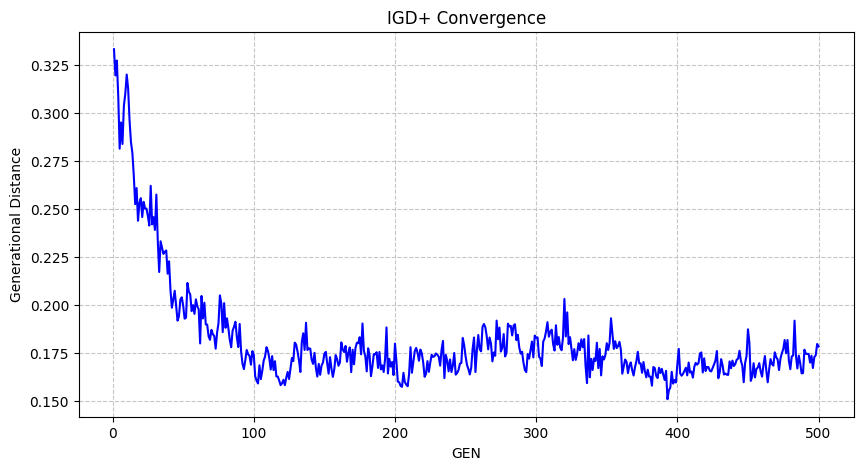

In [ ]:
import matplotlib.pyplot as plt
# 3D Graphic of final pareto front
for ind in tabelas[0]:
   print(ind.fitness.values)
# Hypervolume Graphic
gen = logbook.select("gen")
fit_hv = logbook.select("hypervolume")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_hv, 'b-')
plt.title("Hypervolume Convergence")
plt.xlabel('GEN')
plt.ylabel('Hypervolume')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
# IGD+ Graphic
gen = logbook.select("gen")
fit_igd = logbook.select("igd_plus")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_igd, 'b-')
plt.title("IGD+ Convergence")
plt.xlabel('GEN')
plt.ylabel('Generational Distance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()